In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# loading all 3 files
demand = pd.read_excel("/content/PGCB_date_power_demand.xlsx")
weather = pd.read_excel("/content/weather_data.xlsx")
economic = pd.read_csv("/content/economic_full_1.csv")

print("demand rows:", len(demand))
print("weather rows:", len(weather))
print("economic rows:", len(economic))


demand rows: 92650
weather rows: 107307
economic rows: 1516


In [3]:
demand.head()


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [4]:
weather.head()


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,23.7961,90.3805,9,21600,Asia/Dhaka,GMT+6,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
3,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
4,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0


In [5]:
economic.head()


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [6]:
print("Demand columns:", demand.columns.tolist())
print("Weather columns:", weather.columns.tolist())
print("Economic columns:", economic.columns.tolist())


Demand columns: ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']
Weather columns: ['latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
Economic columns: ['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [7]:
print(demand.shape)
print(demand.dtypes)
print(demand.isnull().sum())


(92650, 15)
datetime                datetime64[ns]
generation_mw                  float64
demand_mw                        int64
load_shedding                    int64
gas                              int64
liquid_fuel                      int64
coal                             int64
hydro                            int64
solar                          float64
wind                           float64
india_bheramara_hvdc             int64
india_tripura                    int64
india_adani                    float64
nepal                          float64
remarks                         object
dtype: object
datetime                    0
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                   22133
wind                    73974
india_bheramara_hvdc        0
india_tripura               0
india_adani             85312

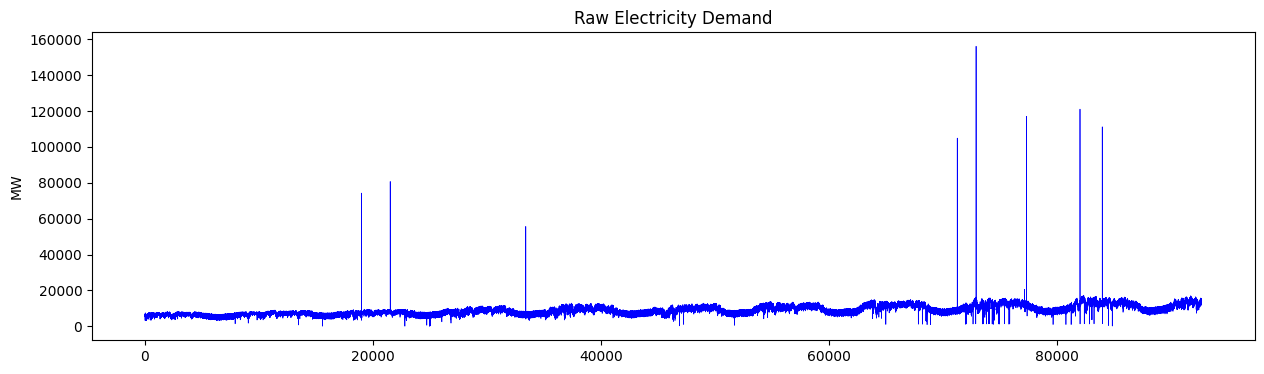

In [8]:
plt.figure(figsize=(15,4))
plt.plot(demand['demand_mw'], color='blue', linewidth=0.5)
plt.title("Raw Electricity Demand")
plt.ylabel("MW")
plt.show()


In [9]:
demand['demand_mw'].describe()


,demand_mw
count,92650.000000
mean,8819.646044
std,2772.150108
min,6.000000
25%,6812.250000
50%,8422.000000
75%,10633.000000
max,156050.000000


In [10]:
print(weather.shape)
print(weather.isnull().sum())
weather.head()


(107307, 10)
latitude                 1
longitude                1
elevation                1
utc_offset_seconds       1
timezone                 1
timezone_abbreviation    1
Unnamed: 6               2
Unnamed: 7               2
Unnamed: 8               2
Unnamed: 9               2
dtype: int64


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,23.7961,90.3805,9,21600,Asia/Dhaka,GMT+6,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
3,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
4,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0


In [11]:
demand['datetime'] = pd.to_datetime(demand['datetime'])
demand = demand.sort_values('datetime').reset_index(drop=True)
demand = demand.drop_duplicates(subset='datetime')

print("After cleaning:", demand.shape)
print(demand['datetime'].min(), "to", demand['datetime'].max())


After cleaning: (92218, 15)
2015-04-19 00:00:00 to 2025-06-17 12:00:00


In [12]:
# remove spikes using 24h rolling window, 3 std threshold
rolling_mean = demand['demand_mw'].rolling(window=24).mean()
rolling_std = demand['demand_mw'].rolling(window=24).std()

upper = rolling_mean + 3 * rolling_std
lower = rolling_mean - 3 * rolling_std

demand.loc[(demand['demand_mw'] > upper) | (demand['demand_mw'] < lower), 'demand_mw'] = np.nan
demand['demand_mw'] = demand['demand_mw'].ffill()

print("spikes removed")
print(demand['demand_mw'].describe())


spikes removed
count    92218.000000
mean      8823.619467
std       2611.438309
min       1306.000000
25%       6822.000000
50%       8434.000000
75%      10641.750000
max      17200.000000
Name: demand_mw, dtype: float64


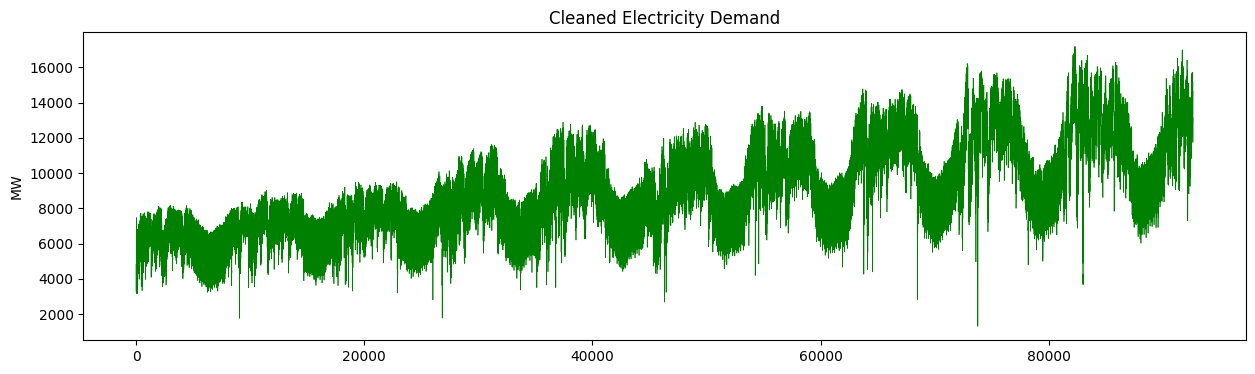

In [13]:
plt.figure(figsize=(15,4))
plt.plot(demand['demand_mw'], color='green', linewidth=0.5)
plt.title("Cleaned Electricity Demand")
plt.ylabel("MW")
plt.show()


In [14]:
# had to reload with skiprows=3, header was off
weather = pd.read_excel("/content/weather_data.xlsx", skiprows=3)
weather.head()


,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [15]:
print(weather.columns.tolist())
print(weather.shape)


['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)']
(107304, 10)


In [16]:
weather = weather.rename(columns={'time': 'datetime'})
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather = weather.sort_values('datetime').reset_index(drop=True)

print(weather['datetime'].min(), "to", weather['datetime'].max())
weather.head()


2014-01-01 00:00:00 to 2026-03-29 23:00:00


,datetime,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [17]:
df = pd.merge(demand[['datetime', 'demand_mw']], weather, on='datetime', how='inner')

print("Merged shape:", df.shape)
df.head()


Merged shape: (88046, 11)


,datetime,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2015-04-19 00:00:00,4821.0,25.7,87,29.6,0.0,23.5,26.7,188,9,0.0
1,2015-04-19 01:00:00,3612.0,25.3,88,30.0,0.0,23.2,26.4,151,26,0.0
2,2015-04-19 02:00:00,3727.0,24.9,90,29.6,0.0,23.2,26.1,152,32,0.0
3,2015-04-19 03:00:00,3632.0,25.0,90,29.3,0.0,23.3,26.1,171,30,0.0
4,2015-04-19 04:00:00,3641.0,25.2,91,30.3,0.0,23.5,26.0,184,67,0.0


In [18]:
economic = pd.read_csv("/content/economic_full_1.csv")

# checking if Bangladesh is in there
print(economic['Country Name'].unique()[:30])


['X']


In [19]:
# wasnt showing up directly, searched by partial string
mask = economic['Country Name'].str.contains('Bang', case=False, na=False)
print(economic[mask]['Country Name'].unique())


[]


In [20]:
eco_bd = economic[economic['Country Name'] == 'Bangladesh']
print(eco_bd.shape)
eco_bd.head()


(0, 69)


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025


In [21]:
# picking indicators relevent to electricity demand
useful = [
    'GDP (current US$)',
    'Population, total',
    'Urban population',
    'Industry (including construction), value added (% of GDP)',
    'Electric power consumption (kWh per capita)'
]

eco_filtered = economic[economic['Indicator Name'].isin(useful)].copy()
year_cols = [str(y) for y in range(2010, 2026)]
eco_small = eco_filtered[['Indicator Name'] + year_cols].copy()

# transpose so years become rows
eco_small = eco_small.set_index('Indicator Name').T.reset_index()
eco_small = eco_small.rename(columns={'index': 'year'})
eco_small['year'] = eco_small['year'].astype(int)

print(eco_small.shape)
eco_small.head()


(16, 6)


Indicator Name,year,Urban population,"Population, total",GDP (current US$),"Industry (including construction), value added (% of GDP)",Electric power consumption (kWh per capita)
0,2010,42198665.0,152201981.0,1.152760e+11,24.956477,239.944314
1,2011,43174476.0,153591076.0,1.286070e+11,25.045300,258.882228
2,2012,44162100.0,155070101.0,1.333110e+11,25.309959,276.694216
3,2013,45144971.0,156532141.0,1.499990e+11,26.307070,296.341695
4,2014,46116983.0,157964929.0,1.728870e+11,26.311047,326.502853


In [22]:
df['year'] = df['datetime'].dt.year
df = pd.merge(df, eco_small, on='year', how='left')

print("Final shape:", df.shape)
df.head()


Final shape: (88046, 17)


,datetime,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),year,Urban population,"Population, total",GDP (current US$),"Industry (including construction), value added (% of GDP)",Electric power consumption (kWh per capita)
0,2015-04-19 00:00:00,4821.0,25.7,87,29.6,0.0,23.5,26.7,188,9,0.0,2015,47081010.0,159383179.0,1.951470e+11,26.831395,348.932681
1,2015-04-19 01:00:00,3612.0,25.3,88,30.0,0.0,23.2,26.4,151,26,0.0,2015,47081010.0,159383179.0,1.951470e+11,26.831395,348.932681
2,2015-04-19 02:00:00,3727.0,24.9,90,29.6,0.0,23.2,26.1,152,32,0.0,2015,47081010.0,159383179.0,1.951470e+11,26.831395,348.932681
3,2015-04-19 03:00:00,3632.0,25.0,90,29.3,0.0,23.3,26.1,171,30,0.0,2015,47081010.0,159383179.0,1.951470e+11,26.831395,348.932681
4,2015-04-19 04:00:00,3641.0,25.2,91,30.3,0.0,23.5,26.0,184,67,0.0,2015,47081010.0,159383179.0,1.951470e+11,26.831395,348.932681


## Feature Engineering

In [23]:
# basic time features
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)


In [24]:
df = df.sort_values('datetime').reset_index(drop=True)

# lag features - 1h, 2h, 24h, 48h, 1 week
df['lag_1h'] = df['demand_mw'].shift(1)
df['lag_2h'] = df['demand_mw'].shift(2)
df['lag_24h'] = df['demand_mw'].shift(24)
df['lag_48h'] = df['demand_mw'].shift(48)
df['lag_168h'] = df['demand_mw'].shift(168)


In [25]:
df['rolling_mean_3h'] = df['demand_mw'].shift(1).rolling(3).mean()
df['rolling_mean_24h'] = df['demand_mw'].shift(1).rolling(24).mean()
df['rolling_std_24h'] = df['demand_mw'].shift(1).rolling(24).std()


In [26]:
# predict next hour demand
df['target'] = df['demand_mw'].shift(-1)
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)
df.head()


Final shape: (66351, 30)


,datetime,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),...,is_weekend,lag_1h,lag_2h,lag_24h,lag_48h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h,target
0,2015-04-28 00:00:00,4898.0,23.9,93,28.3,0.0,22.7,25.5,153,9,...,0,5246.0,5499.0,5236.0,5197.0,4821.0,5509.666667,5335.916667,499.230009,4690.0
1,2015-04-28 01:00:00,4690.0,23.7,93,28.0,0.0,22.5,25.2,173,4,...,0,4898.0,5246.0,5064.0,4987.0,3612.0,5214.333333,5321.833333,506.880113,4573.0
2,2015-04-28 02:00:00,4573.0,23.6,94,28.0,0.0,22.6,25.2,194,10,...,0,4690.0,4898.0,4851.0,4703.0,3727.0,4944.666667,5306.250000,520.711825,4442.0
3,2015-04-28 03:00:00,4442.0,23.6,95,28.0,0.0,22.7,25.1,205,9,...,0,4573.0,4690.0,4690.0,4510.0,3632.0,4720.333333,5294.666667,534.196729,4440.0
4,2015-04-28 04:00:00,4440.0,23.3,96,27.7,0.0,22.6,24.9,202,15,...,0,4442.0,4573.0,4717.0,4230.0,3641.0,4568.333333,5284.333333,548.606033,4288.0


In [27]:
print("df datetime min:", df['datetime'].min())
print("df datetime max:", df['datetime'].max())

train = df[df['datetime'] < '2022-01-01']
test = df[df['datetime'] >= '2022-01-01']

print("Train size:", train.shape)
print("Test size:", test.shape)


df datetime min: 2015-04-28 00:00:00
df datetime max: 2022-12-31 23:00:00
Train size: (57606, 30)
Test size: (8745, 30)


In [28]:
drop_cols = ['datetime', 'demand_mw', 'target', 'year']

X_train = train.drop(columns=drop_cols)
y_train = train['target']
X_test = test.drop(columns=drop_cols)
y_test = test['target']

# lgbm doesnt like special chars in col names
def clean_col_names(df):
    new_cols = []
    for col in df.columns:
        col = col.replace(' (°C)', '_C').replace(' (%)', '_pct').replace(' (mm)', '_mm')
        col = col.replace(' (°)', '_deg').replace(' (s)', '_s')
        col = col.replace('.', '_').replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
        new_cols.append(col)
    df.columns = new_cols
    return df

X_train = clean_col_names(X_train)
X_test = clean_col_names(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (57606, 26)
X_test: (8745, 26)


## Models
trying lgbm, random forest and linear regression

In [29]:
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-10))) * 100

def show_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    m = mape(y_true, y_pred)
    print(f"{name}  |  MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.4f}  MAPE: {m:.2f}%")

# lgbm
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
show_metrics(y_test, lgb_pred, "LightGBM")

# random forest - slower but usually solid
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
show_metrics(y_test, rf_pred, "RandomForest")

# linear regression as baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
show_metrics(y_test, lr_pred, "LinearRegression")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008987 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3896
[LightGBM] [Info] Number of data points in the train set: 57606, number of used features: 26
[LightGBM] [Info] Start training from score 7654.789692
LightGBM  |  MAE: 346.18  RMSE: 473.66  R2: 0.9530  MAPE: 3.35%
RandomForest  |  MAE: 379.69  RMSE: 539.36  R2: 0.9390  MAPE: 3.63%
LinearRegression  |  MAE: 449.61  RMSE: 620.60  R2: 0.9193  MAPE: 4.62%


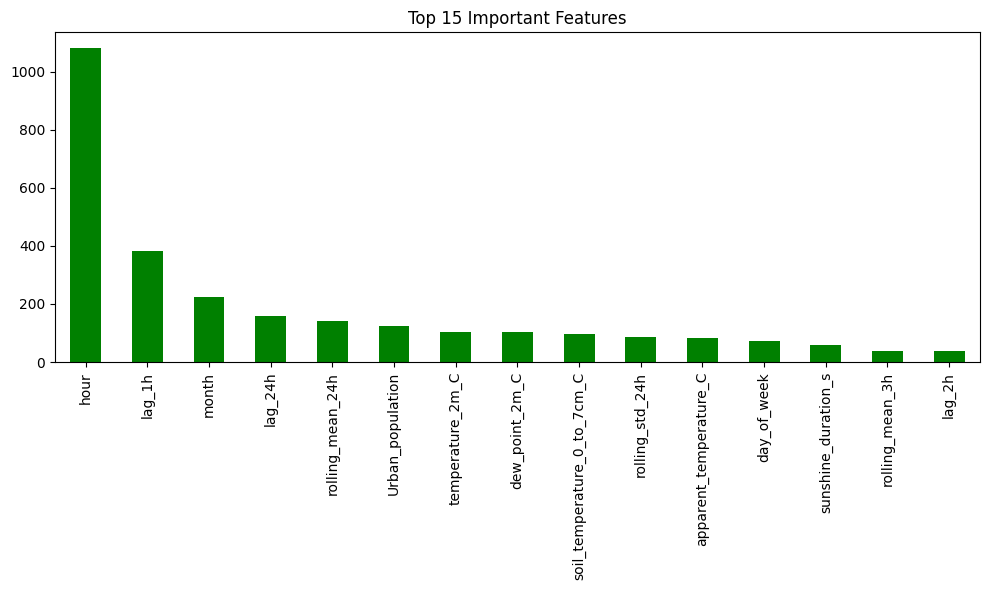

In [30]:
feat_imp = pd.Series(lgb_model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='green')
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()
